# Data Augmentation

## 1. Imports

In [1]:
import pandas as pd
import json
import uuid
import os
import time
from PIL import Image
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

from utils.utils_preproc import *
from utils.utils_augmentation import *
from utils.utils_model import *

In [2]:
# 1. Load the CSVs without 'dx_encoded' (since it's not in the file)
train_df = pd.read_csv('data/train_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
val_df = pd.read_csv('data/val_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
test_df = pd.read_csv('data/test_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path','dx']]

# 2. Re-create the encoded column using the loaded dictionary
train_df["dx_encoded"] = train_df["dx"].map(label2idx).astype(int)
val_df["dx_encoded"] = val_df["dx"].map(label2idx).astype(int)
test_df["dx_encoded"] = test_df["dx"].map(label2idx).astype(int)

In [3]:
train_df.head()

,image_id,dataset,lesion_id,cleaned_path,dx,dx_encoded
0,ISIC_0024306,vidir_molemax,HAM_0000550,./data\HAM10000_cleaned\train\ISIC_0024306_cle...,nv,5
1,ISIC_0024307,vidir_molemax,HAM_0003577,./data\HAM10000_cleaned\train\ISIC_0024307_cle...,nv,5
2,ISIC_0024308,vidir_molemax,HAM_0001477,./data\HAM10000_cleaned\train\ISIC_0024308_cle...,nv,5
3,ISIC_0024309,vidir_molemax,HAM_0000484,./data\HAM10000_cleaned\train\ISIC_0024309_cle...,nv,5
4,ISIC_0024311,vidir_molemax,HAM_0000981,./data\HAM10000_cleaned\train\ISIC_0024311_cle...,nv,5


In [4]:
train_df = train_df.rename(columns={'cleaned_path': 'image_path'})
val_df = val_df.rename(columns={'cleaned_path': 'image_path'})
test_df = test_df.rename(columns={'cleaned_path': 'image_path'})

train_df['dataset'] = 'original'
val_df['dataset'] = 'original'
test_df['dataset'] = 'original'

In [5]:
train_df.head()

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
0,ISIC_0024306,original,HAM_0000550,./data\HAM10000_cleaned\train\ISIC_0024306_cle...,nv,5
1,ISIC_0024307,original,HAM_0003577,./data\HAM10000_cleaned\train\ISIC_0024307_cle...,nv,5
2,ISIC_0024308,original,HAM_0001477,./data\HAM10000_cleaned\train\ISIC_0024308_cle...,nv,5
3,ISIC_0024309,original,HAM_0000484,./data\HAM10000_cleaned\train\ISIC_0024309_cle...,nv,5
4,ISIC_0024311,original,HAM_0000981,./data\HAM10000_cleaned\train\ISIC_0024311_cle...,nv,5


## 2. Offline Augmentation

In [7]:
# TEST (CPU - 1min)
output_csv = os.path.join(base_path, "augmented_metadata.csv")

aug_train_df = run_augmentation_pipeline(
            train_df=train_df,
            undersample=True,
            undersample_size=4500,
            output_path=output_csv
        )

AUGMENTATION PIPELINE

[1/3] Generating augmented images...
Submitting task for augmenting mel (multiplier: 3)
Submitting task for augmenting bkl (multiplier: 3)
Submitting task for augmenting bcc (multiplier: 4)
Submitting task for augmenting akiec (multiplier: 5)
Submitting task for augmenting vasc (multiplier: 8)
Submitting task for augmenting df (multiplier: 8)


Generating all augmented images: 100%|██████████| 6/6 [03:43<00:00, 37.25s/it]


Generated 9011 augmented images

[2/3] Undersampling 'nv' to 4500 samples...
Undersampled to 4500 samples

[3/3] Combining datasets...
Final dataset size: 16717 samples

Saved to: ./data\augmented_metadata.csv

FINAL CLASS DISTRIBUTION
dx
akiec    1555
bcc      1948
bkl      3231
df       1152
mel      3099
nv       4500
vasc     1232
Name: count, dtype: int64


### 2.2 Visuals

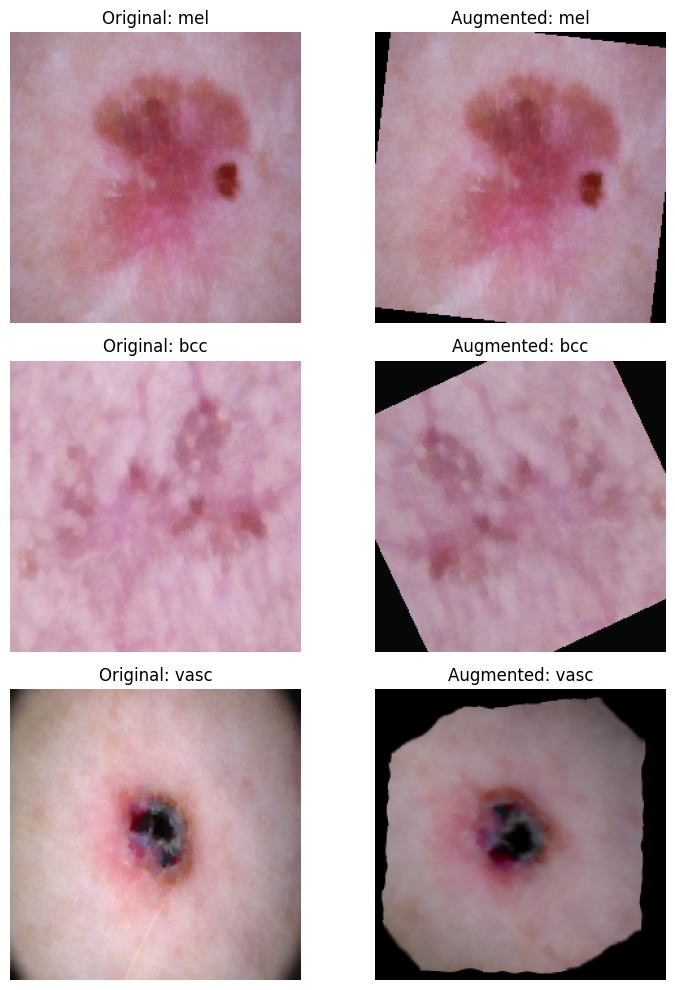

In [11]:
test_labels = ['mel', 'bcc', 'vasc']
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

for i, label in enumerate(test_labels):
    sample_path = train_df[train_df['dx'] == label].sample(1).iloc[0]['image_path']

    # open once
    with Image.open(sample_path) as img:
        img = img.convert("RGB")
        original = transforms.Resize((224, 224))(img)
        aug_tensor = strategy_map[label](original)

    aug_final = denormalize(aug_tensor, mean, std)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original: {label}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(aug_final)
    axes[i, 1].set_title(f"Augmented: {label}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

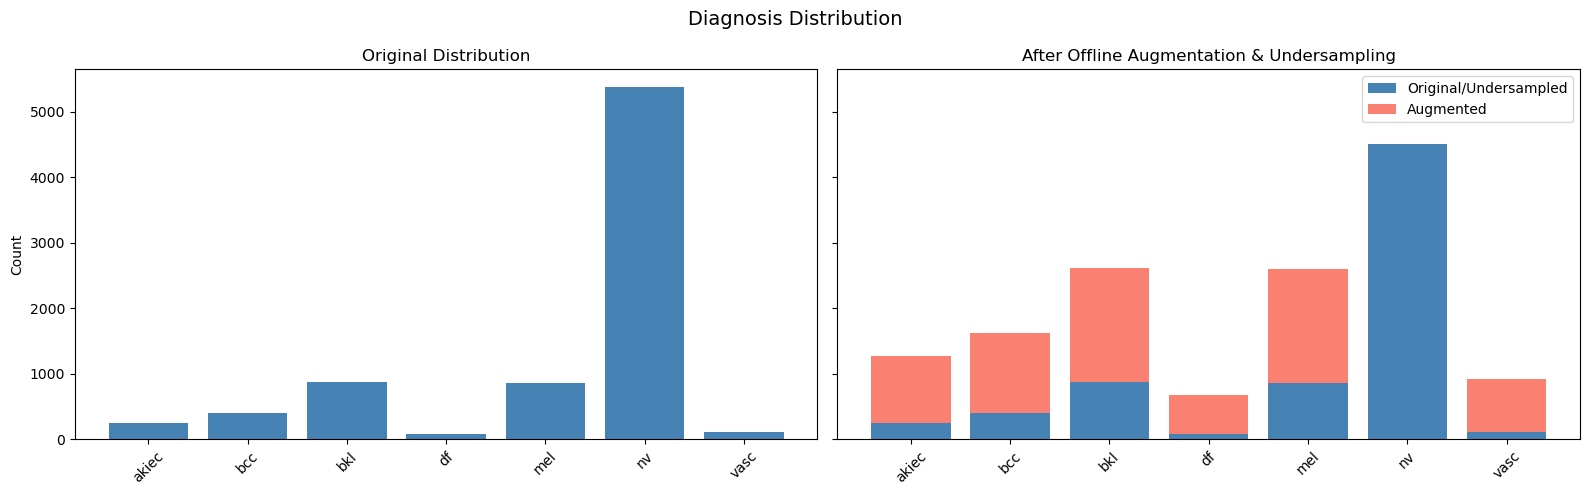

In [ ]:
labels = sorted(aug_train_df["dx"].unique())
 
# Get original counts (unmodified)
original_counts = [len(train_df[train_df["dx"] == l]) for l in labels]
 
# Get final counts from augmented dataframe
final_counts = [len(aug_train_df[aug_train_df["dx"] == l]) for l in labels]
 
# For right chart: separate undersampled/original from augmented
undersampled_or_original = []
augmented_only = []
for i, label in enumerate(labels):
    if label == 'nv':
        # nv was undersampled to 4500
        undersampled_or_original.append(4500)
        augmented_only.append(final_counts[i] - 4500)
    else:
        # Other classes: original count + augmentation
        undersampled_or_original.append(original_counts[i])
        augmented_only.append(final_counts[i] - original_counts[i])
 
x = np.arange(len(labels))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
 
# ── Left: Original Distribution
axes[0].bar(x, original_counts, color="steelblue")
axes[0].set_title("Original Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_ylabel("Count")
 
# ── Right: After Augmentation & Undersampling (stacked)
axes[1].bar(x, undersampled_or_original, color="steelblue", label="Original/Undersampled")
axes[1].bar(x, augmented_only, bottom=undersampled_or_original, color="salmon", label="Augmented")
axes[1].set_title("After Offline Augmentation & Undersampling")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()
 
plt.suptitle("Diagnosis Distribution", fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Augmentation impact on modelling  

In [8]:
aug_train_df.sample(5)

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
6348,ISIC_0027523,original,HAM_0001498,./data\HAM10000_cleaned\train\ISIC_0027523_cle...,nv,5
14572,AUG_akiec_1ef79640,augmented,AUG_LESION_akiec_2acac6fd,./data\HAM10000_augmented\AUG_akiec_1ef79640.jpg,akiec,0
14045,AUG_akiec_24a08a42,augmented,AUG_LESION_akiec_595ff0c4,./data\HAM10000_augmented\AUG_akiec_24a08a42.jpg,akiec,0
6665,ISIC_0024348,original,HAM_0002426,./data\HAM10000_cleaned\train\ISIC_0024348_cle...,nv,5
12187,AUG_bcc_62942dce,augmented,AUG_LESION_bcc_f45419df,./data\HAM10000_augmented\AUG_bcc_62942dce.jpg,bcc,1


In [9]:
# Class weights
N_CLASSES = 7
class_weights_dict = make_class_weights(aug_train_df)

In [10]:
train_ds = make_dataset_new(aug_train_df, shuffle=True, repeat=True)  
val_ds   = make_dataset_new(val_df)                               
test_ds  = make_dataset_new(test_df)

### 2.3.1 Baseline Model 1

In [11]:
N_CLASSES = 7

model_baseline = keras.Sequential([
    keras.layers.Conv2D(8, kernel_size=6, activation="relu", input_shape=(224, 224, 3)),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(N_CLASSES)
])

model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

c:\Users\tomas\anaconda3\envs\clean_ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# CPU - 2min
batch_time_cb_off = BatchTimeCallback()
epochs = 10
spe = 100

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=spe,
    class_weight=class_weights_dict,
    callbacks=[batch_time_cb_off]
)


avg_batch_off = sum(batch_time_cb_off.batch_times) / len(batch_time_cb_off.batch_times)
avg_epoch_off = sum(batch_time_cb_off.epoch_times) / len(batch_time_cb_off.epoch_times)
print(f"Avg batch time (offline): {avg_batch_off:.4f} s/step")
print(f"Avg epoch time (offline): {avg_epoch_off:.1f} s")

Epoch 1/10


100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 233ms/step - accuracy: 0.1213 - loss: 12.2705 - val_accuracy: 0.0477 - val_loss: 1.9134
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.1203 - loss: 1.9561 - val_accuracy: 0.0755 - val_loss: 1.9162
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.1472 - loss: 1.9162 - val_accuracy: 0.0807 - val_loss: 1.9145
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.1281 - loss: 1.9178 - val_accuracy: 0.0547 - val_loss: 1.9050
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.2184 - loss: 1.9016 - val_accuracy: 0.3238 - val_loss: 1.9104
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.2531 - loss: 1.8591 - val_accuracy: 0.3030 - val_loss: 1.8934
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 227ms/step - accuracy: 0.2531 - loss: 1.8553 - val_accuracy: 0.6345 - val_loss: 1.8350
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - accuracy: 0.3041 - loss: 1.8588 - va

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - accuracy: 0.2438 - loss: 1.9237 - val_accuracy: 0.1167 - val_loss: 1.9238
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.2225 - loss: 1.9619 - val_accuracy: 0.4484 - val_loss: 1.9023
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.3166 - loss: 1.9438 - val_accuracy: 0.6027 - val_loss: 1.8023
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.2856 - loss: 1.9062 - val_accuracy: 0.2893 - val_loss: 1.9447
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2678 - loss: 1.9276 - val_accuracy: 0.4291 - val_loss: 1.8057
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2909 - loss: 1.8890 - val_accuracy: 0.4253 - val_loss: 1.7227
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2894 - loss: 1.9128 - val_accuracy: 0.1745 - val_loss: 2.1366
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2844 - loss: 1.8876 - val_accuracy: 0.4185 - val_loss: 1.6894
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.3013 - loss: 1.8557 - val_accuracy: 0.4243 - val_loss: 1.6799
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2666 - loss: 1.9082 - val_accuracy: 0.4118 - val_loss: 1.8139

### 2.3.2 Baseline Model 2

In [13]:
model_baseline2 = keras.Sequential([
    keras.layers.Conv2D(16, 3, activation="relu", padding="same", input_shape=(224, 224, 3)),
    keras.layers.MaxPooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(N_CLASSES)
])

model_baseline2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

c:\Users\tomas\anaconda3\envs\clean_ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# CPU - ~4min
epochs = 10
spe = 100

history_baseline2 = model_baseline2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=spe,
    class_weight=class_weights_dict,
    callbacks=[batch_time_cb_off]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 92s 351ms/step - accuracy: 0.3331 - loss: 1.7492 - val_accuracy: 0.0069 - val_loss: 4.3917
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 298ms/step - accuracy: 0.4481 - loss: 1.4143 - val_accuracy: 0.1215 - val_loss: 2.2758
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 343ms/step - accuracy: 0.4931 - loss: 1.2881 - val_accuracy: 0.2179 - val_loss: 1.9660
Epoch 4/10
 11/100 ━━━━━━━━━━━━━━━━━━━━ 23s 260ms/step - accuracy: 0.5543 - loss: 1.1747

Epoch 1/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m27s[0m 215ms/step - accuracy: 0.3753 - loss: 1.7235 - val_accuracy: 0.6326 - val_loss: 1.6615
Epoch 2/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m21s[0m 214ms/step - accuracy: 0.4631 - loss: 1.5133 - val_accuracy: 0.4417 - val_loss: 1.6122
Epoch 3/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m23s[0m 235ms/step - accuracy: 0.5362 - loss: 1.3060 - val_accuracy: 0.4513 - val_loss: 1.4502
Epoch 4/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m23s[0m 232ms/step - accuracy: 0.5487 - loss: 1.1898 - val_accuracy: 0.6104 - val_loss: 1.2646
Epoch 5/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 222ms/step - accuracy: 0.5859 - loss: 1.1003 - val_accuracy: 0.6095 - val_loss: 1.1932
Epoch 6/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m25s[0m 248ms/step - accuracy: 0.5953 - loss: 1.0614 - val_accuracy: 0.4986 - val_loss: 1.2919
Epoch 7/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 219ms/step - accuracy: 0.6012 - loss: 1.0193 - val_accuracy: 0.6191 - val_loss: 1.0305
Epoch 8/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m21s[0m 211ms/step - accuracy: 0.6019 - loss: 1.0189 - val_accuracy: 0.0164 - val_loss: 11.7091
Epoch 9/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 220ms/step - accuracy: 0.6097 - loss: 0.9649 - val_accuracy: 0.5333 - val_loss: 1.1624
Epoch 10/10
[1m100/100[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m22s[0m 222ms/step - accuracy: 0.6353 - loss: 0.9329 - val_accuracy: 0.5265 - val_loss: 1.2727

## 3. Online Augmentation

### 3.1 Augmentation impact on modelling

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

#random trnasforms in each epoch
train_datagen_on = ImageDataGenerator(
    preprocessing_function=preprocess_imagenet,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=90,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    shear_range=10,
    fill_mode='nearest'
)

val_datagen_on = ImageDataGenerator(
    preprocessing_function=preprocess_imagenet
)

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

classes_ordered = [k for k, v in sorted(label2idx.items(), key=lambda x: x[1])]

train_gen_on = train_datagen_on.flow_from_dataframe(
    dataframe  = train_df,
    x_col      = 'image_path',
    y_col      = 'dx',
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'sparse',
    classes    = classes_ordered,
    shuffle    = True
)

val_gen_on = val_datagen_on.flow_from_dataframe(
    dataframe  = val_df,
    x_col      = 'image_path',
    y_col      = 'dx',
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'sparse',
    classes    = classes_ordered,
    shuffle    = False
)


Found 7976 validated image filenames belonging to 7 classes.
Found 1037 validated image filenames belonging to 7 classes.


In [ ]:
model_on_keras = keras.Sequential([
    keras.layers.Conv2D(8, kernel_size=6, activation="relu",
                        input_shape=(224, 224, 3)),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(N_CLASSES)
])

model_on_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

epochs_on = 10
spe_on    = 100   

class_weights_dict_on = make_class_weights(train_df) 
batch_time_cb_on = BatchTimeCallback()

history_online = model_on_keras.fit(
    train_gen_on,
    validation_data = val_gen_on,
    epochs          = epochs_on,
    steps_per_epoch = spe_on,
    class_weight    = class_weights_dict_on,
    callbacks       = [batch_time_cb_on]
)

avg_batch_on = sum(batch_time_cb_on.batch_times) / len(batch_time_cb_on.batch_times)
avg_epoch_on = sum(batch_time_cb_on.epoch_times) / len(batch_time_cb_on.epoch_times)
print(f"\nAvg batch time (online): {avg_batch_on:.4f} s/step")
print(f"Avg epoch time (online): {avg_epoch_on:.1f} s")


c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 796ms/step - accuracy: 0.1916 - loss: 1.8944 - val_accuracy: 0.4002 - val_loss: 1.9053
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 655ms/step - accuracy: 0.4178 - loss: 1.9128 - val_accuracy: 0.4291 - val_loss: 1.7083
Epoch 3/10
 50/100 ━━━━━━━━━━━━━━━━━━━━ 26s 535ms/step - accuracy: 0.4410 - loss: 1.9317

c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 322ms/step - accuracy: 0.4391 - loss: 1.8764 - val_accuracy: 0.4436 - val_loss: 1.7432
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 597ms/step - accuracy: 0.4632 - loss: 1.8728 - val_accuracy: 0.4590 - val_loss: 1.6746
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 608ms/step - accuracy: 0.4741 - loss: 1.8719 - val_accuracy: 0.4716 - val_loss: 1.6335
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - accuracy: 0.4856 - loss: 1.7173 - val_accuracy: 0.4793 - val_loss: 1.5874
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 578ms/step - accuracy: 0.4635 - loss: 1.8625 - val_accuracy: 0.4002 - val_loss: 1.6818
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 578ms/step - accuracy: 0.4416 - loss: 1.7828 - val_accuracy: 0.4243 - val_loss: 1.6353
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 290ms/step - accuracy: 0.4300 - loss: 1.6591 - val_accuracy: 0.4204 - val_loss: 1.5966
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 572ms/step - accuracy: 0.4119 - loss: 1.8609 - va

## 4. Augmentation comparison

In [ ]:
avg_batch_off = sum(batch_time_cb_off.batch_times) / len(batch_time_cb_off.batch_times)
avg_epoch_off = sum(batch_time_cb_off.epoch_times) / len(batch_time_cb_off.epoch_times)

comparison_df = pd.DataFrame({
    "Metric": [
        "Dataset (train)",
        "Avg batch time (s/step)",
        "Avg epoch time (s)",
        "Final val accuracy",
    ],
    "Offline (pre-generated images)": [
        f"{len(aug_train_df)} samples (original + generated)",
        f"{avg_batch_off:.4f}",
        f"{avg_epoch_off:.1f}",
        f"{history_baseline.history['val_accuracy'][-1]:.4f}",
    ],
    "Online (real-time transforms)": [
        f"{len(train_df)} samples (original)",
        f"{avg_batch_on:.4f}",
        f"{avg_epoch_on:.1f}",
        f"{history_online.history['val_accuracy'][-1]:.4f}",
    ],
})
comparison_df


,Metric,Offline (pre-generated images),Online (real-time transforms)
0,Dataset (train),14214 samples (original + sintéticas),7976 samples (só originais)
1,Avg batch time (s/step),0.1032,0.5540
2,Avg epoch time (s),12.9,53.0
3,Final val accuracy,0.4860,0.4031


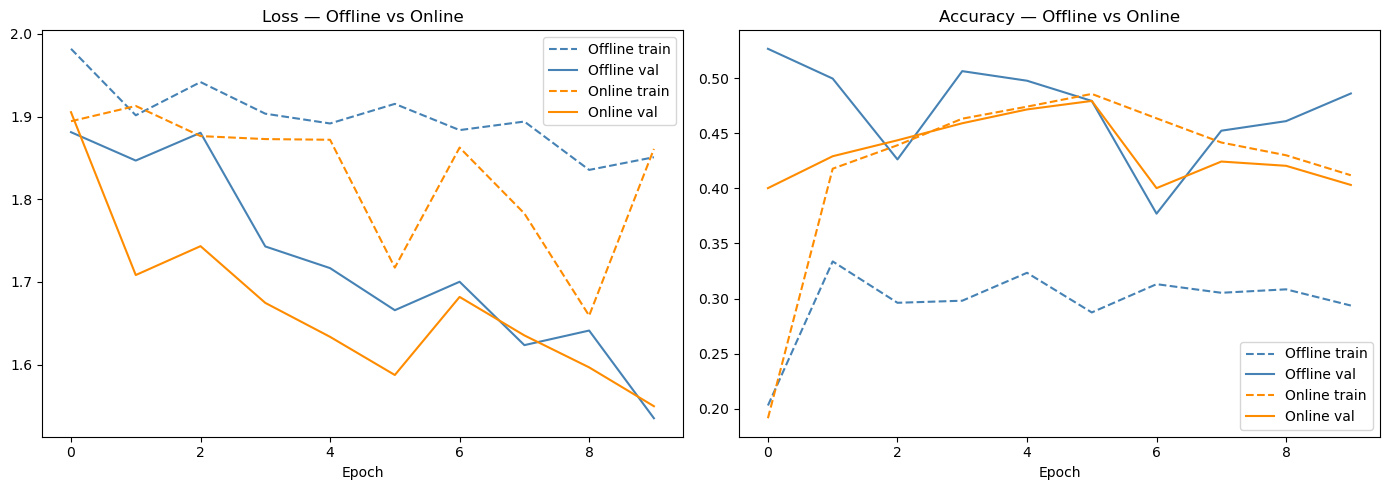

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history["loss"],     label="Offline train", linestyle="--", color="steelblue")
axes[0].plot(history_baseline.history["val_loss"], label="Offline val",                  color="steelblue")
axes[0].plot(history_online.history["loss"],       label="Online train",  linestyle="--", color="darkorange")
axes[0].plot(history_online.history["val_loss"],   label="Online val",                   color="darkorange")
axes[0].set_title("Loss — Offline vs Online")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_baseline.history["accuracy"],     label="Offline train", linestyle="--", color="steelblue")
axes[1].plot(history_baseline.history["val_accuracy"], label="Offline val",                  color="steelblue")
axes[1].plot(history_online.history["accuracy"],       label="Online train",  linestyle="--", color="darkorange")
axes[1].plot(history_online.history["val_accuracy"],   label="Online val",                   color="darkorange")
axes[1].set_title("Accuracy — Offline vs Online")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()
